# 2. Hafta: Matematiksel Notasyonlar ve Asimptotik Analiz

Algoritmaların performansını ve ne kadar kaynak (zaman/hafıza) tüketeceğini ölçmek için **Asimptotik Analiz** kullanırız. Girdi boyutu ($n$) sonsuza yaklaşırken algoritmanın çalışma süresinin nasıl değiştiğiyle ilgileniriz. 

En yaygın kullanılan üç temel matematiksel notasyon şunlardır:

* **Big-O Notasyonu ($O$) - Üst Sınır:** Algoritmanın **en kötü senaryodaki** büyüme hızını ifade eder. Algoritma "en fazla bu kadar zaman/işlem harcar" deriz. Bize maksimum süre garantisini verir.

* **Omega Notasyonu ($\Omega$) - Alt Sınır:** Algoritmanın **en iyi senaryodaki** büyüme hızını ifade eder. Algoritma "şartlar ne kadar mükemmel olursa olsun, en az bu kadar zaman/işlem harcar" deriz. Bize inebileceği minimum işlem sınırını gösterir.

* **Theta Notasyonu ($\Theta$) - Kesin Sınır:** Algoritmanın **ortalama senaryodaki** büyüme hızını ifade eder. Alt ve üst sınır aynı büyüme oranına sahipse kullanılır.


## Büyüme Hızlarının Karşılaştırılması (Görselleştirme)

Farklı zaman karmaşıklıklarının ($O(1)$, $O(\log n)$, $O(n)$, $O(n \log n)$, $O(n^2)$) girdi boyutu arttıkça nasıl davrandığını görmek için Python'un `matplotlib` kütüphanesini kullanarak bir grafik çizelim.

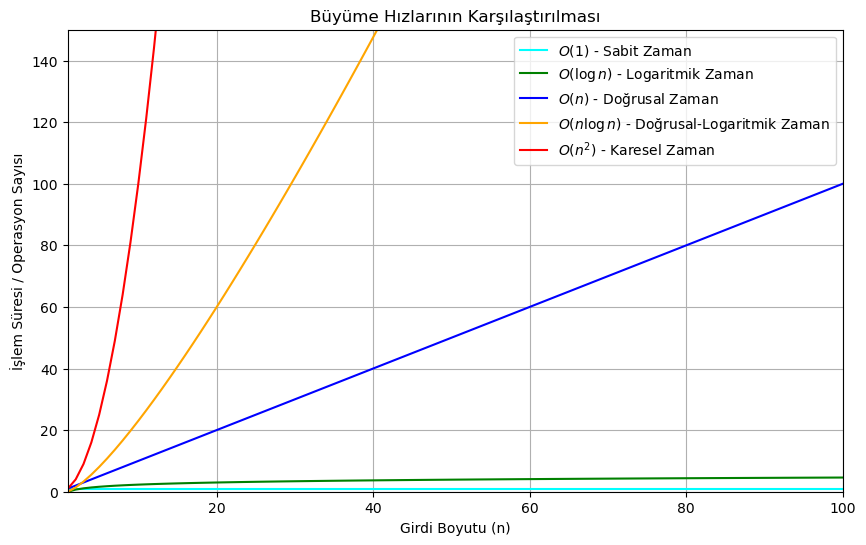

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore") # Logaritmik uyariları gizlemek için

n = np.linspace(1, 100, 100)

# Karmaşıklık Fonksiyonları
O_1 = np.ones_like(n)
O_log_n = np.log(n)
O_n = n
O_n_log_n = n * np.log(n)
O_n_square = n**2

# Grafiği çizdirme
plt.figure(figsize=(10, 6))

plt.plot(n, O_1, label=r'$O(1)$ - Sabit Zaman', color='cyan')
plt.plot(n, O_log_n, label=r'$O(\log n)$ - Logaritmik Zaman', color='green')
plt.plot(n, O_n, label=r'$O(n)$ - Doğrusal Zaman', color='blue')
plt.plot(n, O_n_log_n, label=r'$O(n \log n)$ - Doğrusal-Logaritmik Zaman', color='orange')
plt.plot(n, O_n_square, label=r'$O(n^2)$ - Karesel Zaman', color='red')

plt.ylim(0, 150)
plt.xlim(1, 100)
plt.xlabel('Girdi Boyutu (n)')
plt.ylabel('İşlem Süresi / Operasyon Sayısı')
plt.title('Büyüme Hızlarının Karşılaştırılması')
plt.legend()
plt.grid(True)
plt.show()

## Kod Parçacıkları Üzerinde Karmaşıklık Hesabı

Şimdi teorik olarak gördüğümüz bu karmaşıklık sınıflarını basit Python kod parçacıkları üzerinden inceleyelim.

In [3]:
# 1. Sabit Zaman Karmaşıklığı: O(1)

def ilk_elemani_getir(dizi):
    if len(dizi) > 0:
        return dizi[0]
    return None

test_dizisi = [10, 20, 30, 40, 50]
print("O(1) Örneği:", ilk_elemani_getir(test_dizisi))

O(1) Örneği: 10


In [2]:
# 2. Doğrusal Zaman Karmaşıklığı: O(n)

def diziyi_yazdir_ve_topla(dizi):
    toplam = 0
    for eleman in dizi:
        toplam += eleman
    return toplam

test_dizisi = [10, 20, 30, 40, 50] 

print("O(n) Örneği Toplam:", diziyi_yazdir_ve_topla(test_dizisi))

O(n) Örneği Toplam: 150


In [7]:
# 3. Karesel Zaman Karmaşıklığı: O(n^2)

def ikili_kombinasyonlari_yazdir(dizi):
    n = len(dizi)
    adim_sayisi = 0
    for i in range(n):
        for j in range(n):
            adim_sayisi += 1
    return adim_sayisi

n_kare_adim = ikili_kombinasyonlari_yazdir(test_dizisi)
print(f"O(n^2) Örneği: {len(test_dizisi)} eleman için toplam {n_kare_adim} adım çalıştı.")

O(n^2) Örneği: 5 eleman için toplam 25 adım çalıştı.


In [1]:
# 4. Logaritmik Zaman Karmaşıklığı: O(log n)

def ikili_arama(sirali_dizi, hedef):
    baslangic = 0
    bitis = len(sirali_dizi) - 1
    adim = 0
    
    while baslangic <= bitis:
        adim += 1
        orta = (baslangic + bitis) // 2
        
        if sirali_dizi[orta] == hedef:
            return f"Bulundu! İndeks: {orta}, {adim} adımda."
        elif sirali_dizi[orta] < hedef:
            baslangic = orta + 1
        else:
            bitis = orta - 1
            
    return "Bulunamadı."

sirali_test_dizisi = list(range(1, 101))
print("O(log n) Örneği:", ikili_arama(sirali_test_dizisi, 73))

# 5. Aynı Algoritmada En İyi (Omega), Ortalama (Theta) ve En Kötü (Big-O) Durumlar

def durum_analizi_arama(dizi, aranan):
    adim = 0
    for eleman in dizi:
        adim += 1
        if eleman == aranan:
            return f"{adim}. adımda bitti."
    return f"Bulunamadı Toplam {adim} adım sürdü."

ornek_dizi = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

# 1. En İyi Durum - Omega(1): Aradığımız eleman dizinin en başındaysa.
print("En İyi Senaryo (Omega):", durum_analizi_arama(ornek_dizi, 10))

# 2. Ortalama Durum - Theta(n): Aradığımız eleman dizinin ortalarındaysa.
print("Ortalama Senaryo (Theta):", durum_analizi_arama(ornek_dizi, 50))

# 3. En Kötü Durum - O(n): Aradığımız eleman dizinin en sonundaysa veya hiç yoksa.
print("En Kötü Senaryo (Big-O):", durum_analizi_arama(ornek_dizi, 100))

O(log n) Örneği: Bulundu! İndeks: 72, 6 adımda.
En İyi Senaryo (Omega): 1. adımda bitti.
Ortalama Senaryo (Theta): 5. adımda bitti.
En Kötü Senaryo (Big-O): 10. adımda bitti.


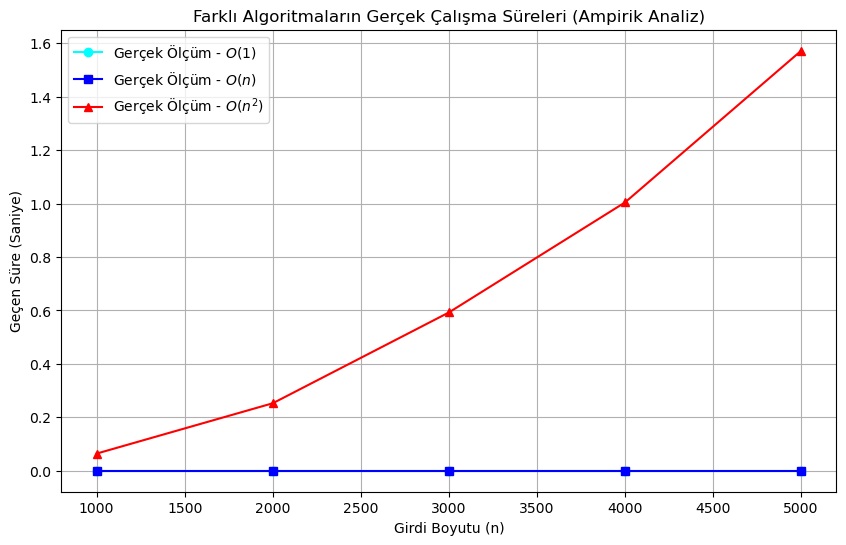

In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt

# O(n^2) çok hızlı büyüyeceği için n değerlerini makul tutuyoruz.
n_degerleri = [1000, 2000, 3000, 4000, 5000]

zaman_O1 = []
zaman_On = []
zaman_On2 = []

for n in n_degerleri:

    test_dizisi = list(range(n))
    
    # 1. O(1) - Sabit Zaman Testi
    baslangic = time.time()
    _ = test_dizisi[0] # Sadece ilk elemana erişim
    bitis = time.time()
    zaman_O1.append(bitis - baslangic)
    
    # 2. O(n) - Doğrusal Zaman Testi
    baslangic = time.time()
    _ = sum(test_dizisi) # Tüm elemanları dolaşarak toplama
    bitis = time.time()
    zaman_On.append(bitis - baslangic)
    
    # 3. O(n^2) - Karesel Zaman Testi
    baslangic = time.time()
    toplam = 0
    for i in test_dizisi:
        for j in test_dizisi:
            toplam += 1
    bitis = time.time()
    zaman_On2.append(bitis - baslangic)

# Gerçek ölçüm sonuçlarını görselleştirme
plt.figure(figsize=(10, 6))
plt.plot(n_degerleri, zaman_O1, label=r'Gerçek Ölçüm - $O(1)$', color='cyan', marker='o')
plt.plot(n_degerleri, zaman_On, label=r'Gerçek Ölçüm - $O(n)$', color='blue', marker='s')
plt.plot(n_degerleri, zaman_On2, label=r'Gerçek Ölçüm - $O(n^2)$', color='red', marker='^')

plt.xlabel('Girdi Boyutu (n)')
plt.ylabel('Geçen Süre (Saniye)')
plt.title('Farklı Algoritmaların Gerçek Çalışma Süreleri (Ampirik Analiz)')
plt.legend()
plt.grid(True)
plt.show()

In [6]:
import time

# 10 Milyon elemanlı devasa bir veri seti oluşturalım
dev_veri_seti = list(range(10_000_000))
aranan_deger = 9_999_999 # En kötü senaryo için sona yakın bir değer seçiyoruz

print(f"Veri Seti Boyutu: {len(dev_veri_seti)} eleman\\n")

# Doğrusal Arama (Linear Search) - O(n) Zaman Ölçümü
basla_linear = time.time()
for eleman in dev_veri_seti:
    if eleman == aranan_deger:
        break
bitis_linear = time.time()
print(f"O(n) Doğrusal Arama Süresi: {bitis_linear - basla_linear:.6f} saniye")

# İkili Arama (Binary Search) - O(log n) Zaman Ölçümü
basla_binary = time.time()
ikili_arama(dev_veri_seti, aranan_deger)
bitis_binary = time.time()
print(f"O(log n) İkili Arama Süresi:   {bitis_binary - basla_binary:.6f} saniye")

# Farkı gösterelim
fark_carpani = (bitis_linear - basla_linear) / (bitis_binary - basla_binary) if (bitis_binary - basla_binary) > 0 else float('inf')
print(f"\\nSonuç: Logaritmik algoritma, doğrusal algoritmaya göre yaklaşık {fark_carpani:,.0f} kat daha hızlı çalıştı")

Veri Seti Boyutu: 10000000 eleman\n
O(n) Doğrusal Arama Süresi: 0.499017 saniye
O(log n) İkili Arama Süresi:   0.000000 saniye
\nSonuç: Logaritmik algoritma, doğrusal algoritmaya göre yaklaşık inf kat daha hızlı çalıştı
